In [ ]:
from pathlib import Path
import sys

# adjust this depending on where the notebook sits
# example: notebook is in project/notebooks/experiments/
PROJECT_ROOT = Path.cwd().resolve().parents[0]   # go up 2 levels

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import yaml
from pathlib import Path
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader


from datasets.bcdata import BCDataDataset, collate_heatmap_points
from datasets.transforms import PointsToLocalizationHeatmap, PointsToCountHeatmap


from visualization import overlay_heatmap
from training import train

from models.models import HybridModel
from models.losses import weighted_sigmoid_mse_from_logits, softplus_mse_from_logits, l1_count_from_density_logits


from utils.debug import print_info
import torch
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)



In [27]:
from tqdm import tqdm
import numpy as np

In [3]:
with open("../config.yaml", "r") as f:
    cfg = yaml.safe_load(f)


data_root = Path(cfg["h200_paths"]["data_root"])
checkpoint_dir = Path(cfg["h200_paths"]["checkpoint_dir"])

print(f"data_root: {data_root}")
print(f"checkpoint_dir: {checkpoint_dir}")

data_root: /raid/datasets/Yeldos/BCData
checkpoint_dir: checkpoints


In [4]:
data_root

PosixPath('/raid/datasets/Yeldos/BCData')

In [5]:
loc_heatmap_generator = PointsToLocalizationHeatmap(out_hw=(160,160), in_hw=(640,640), sigma=2.0)
count_heatmap_generator = PointsToCountHeatmap(out_hw=(160,160), in_hw=(640,640), sigma=2.0)

dataset = BCDataDataset(root = data_root,
                        split="train",
                        target_loc_transform = loc_heatmap_generator,
                        target_count_transform = count_heatmap_generator)

In [8]:
train_loader = DataLoader(
    dataset,
    batch_size=8,        # choose based on GPU memory (640×640 images are large)
    shuffle=False,
    num_workers=0,       # use 0 if debugging
    pin_memory=True,     # recommended when using GPU
    drop_last=True,       # optional, useful for BatchNorm
    collate_fn = collate_heatmap_points
)

In [9]:
model = HybridModel()
device = 'cuda'
model.to(device);

lambda_dens = 1.
lambda_count = 1.

In [10]:
optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=3e-4,
        weight_decay=1e-2
        )

In [11]:
Lmax_list = []
Ldens_list = []
Lcount_list = []


In [12]:
model.train()

for img, loc_heatmap, count_heatmap, pos_pts, neg_pts in tqdm(train_loader):
    # print_info(img, 'img')                              # shape = (B, 3, 640, 640)
    #print_info(loc_heatmap, 'loc_heatmap')              # shape = (B, 2, 160, 160)
    # print_info(count_heatmap, 'count_heatmap')          # shape = (B, 2, 160, 160)
    # print_info(pos_pts, 'pos_pts')                      # shape = list of tensors, len = B
    # print_info(neg_pts, 'neg_pts')                      # shape = list of tensors, len = B


    img = img.to(device)
    loc_heatmap = loc_heatmap.to(device)
    count_heatmap = count_heatmap.to(device)

    pred_loc_hm, pred_den_hm, pred_count = model(img)
    pred_den_hm = pred_den_hm.to(device)
    #print_info(pred_loc_hm, 'pred_loc_hm')                      # shape = (B, 2, 160, 160)
    # print_info(pred_den_hm, 'pred_den_hm')                      # shape = (B, 2, 160, 160)
    # print_info(pred_count, 'pred_count')                      # shape = (B, 2)

    # calculate loss
    Lmax = weighted_sigmoid_mse_from_logits(pred_logits = pred_loc_hm, target = loc_heatmap)
    Ldens = softplus_mse_from_logits(pred_logits = pred_den_hm, target = count_heatmap)
    

    gtN = [(len(tmp1), len(tmp2)) for tmp1, tmp2 in zip(pos_pts, neg_pts)]  # (B, 2)

    gtN = torch.tensor(gtN)
    gtN = gtN.to(device)

    Lcount = l1_count_from_density_logits(pred_logits = pred_den_hm, gtN = gtN)

    loss = Lmax + lambda_dens * Ldens + lambda_count * Lcount


    Lmax_list.append(Lmax.item())
    Ldens_list.append(Ldens.item())
    Lcount_list.append(Lcount.item())

    #print(f"Lmax {Lmax.item()}")
    #print(f"Ldens {Ldens.item()}")
    #print(f"Lcount {Lcount.item()}")
    #print(f"loss {loss.item()}")
    
    loss.backward()
    optimizer.step()

100%|██████████| 100/100 [31:07<00:00, 18.68s/it] 


In [13]:
print(len(Lmax_list))
print(len(Ldens_list))
print(len(Lcount_list))

print(sum(Lmax_list) / len(Lmax_list))
print(sum(Ldens_list) / len(Ldens_list))
print(sum(Lcount_list) / len(Lcount_list))

100
100
100
0.17145150914788246
0.006196881577398017
330.78166481018064


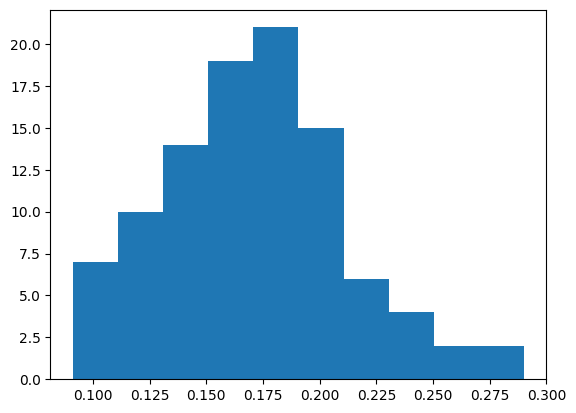

In [14]:
plt.hist(Lmax_list)
plt.show()

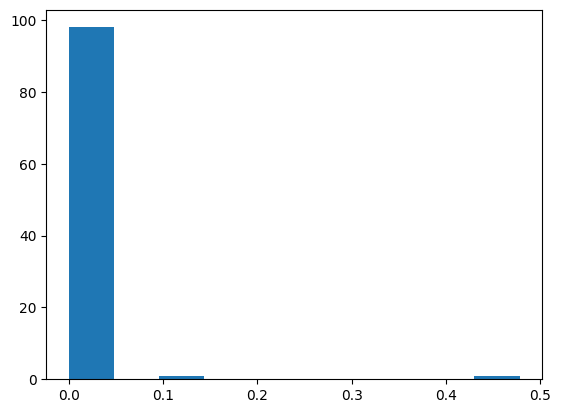

In [15]:
plt.hist(Ldens_list)
plt.show()

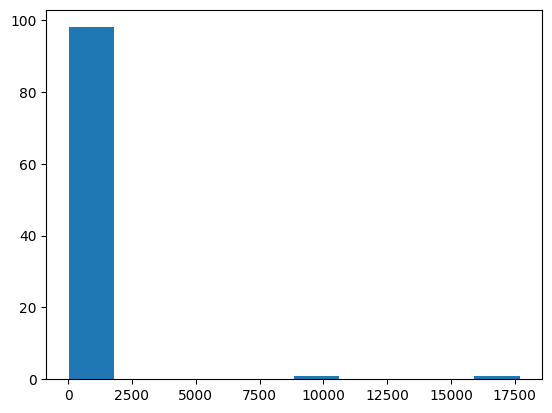

In [16]:
plt.hist(Lcount_list)
plt.show()

In [12]:
#overlay_heatmap(img[0], loc_heatmap[0])
#overlay_heatmap(img[0], count_heatmap[0])


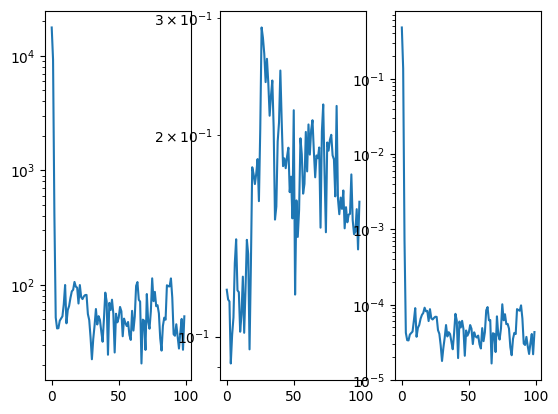

In [23]:
fig, axes = plt.subplots(1, 3)
axes[0].plot(Lcount_list)
axes[0].set_yscale('log')

axes[1].plot(Lmax_list)
axes[1].set_yscale('log')

axes[2].plot(Ldens_list)
axes[2].set_yscale('log')


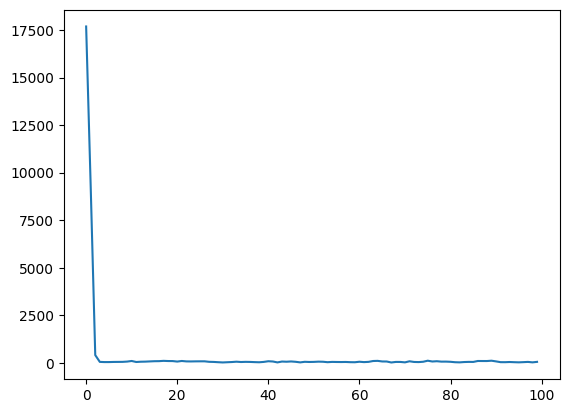

In [25]:
plt.plot(Lcount_list)

In [ ]:
Lcount_list_truncated = Lcount_list[5:]
print(Lcount_list_truncated)




[41.6875, 48.4375, 50.6875, 52.9375, 67.4375, 99.4375, 46.0, 60.1875, 65.25, 76.8125, 87.4375, 90.3125, 105.75, 96.1875, 94.1875, 68.5, 99.3125, 77.75, 74.875, 79.125, 81.25, 81.4375, 55.4375, 49.125, 34.625, 22.3125, 33.5, 44.0, 61.3125, 44.9375, 53.125, 49.1875, 39.1875, 31.75, 50.5, 85.25, 71.75, 24.4375, 69.375, 60.0625, 73.9375, 55.9375, 25.5625, 55.75, 46.875, 51.4375, 63.9375, 58.625, 35.4375, 50.5625, 46.25, 43.5625, 47.25, 36.375, 32.9375, 59.125, 39.75, 52.5625, 97.625, 105.5, 73.875, 71.1875, 20.5, 49.5, 48.5, 26.9375, 82.875, 47.6875, 41.25, 58.5, 113.6875, 71.8125, 86.5625, 64.875, 66.1875, 56.1875, 34.0, 26.5625, 43.625, 51.5, 49.4375, 98.875, 97.0, 96.5625, 113.5, 77.125, 36.9375, 35.8125, 45.125, 35.3125, 27.6875, 38.0, 50.25, 27.0, 52.9375]


In [30]:
print(f"max mean: {np.mean(Lmax_list[5:])}")
print(f"dense mean: {np.mean(Ldens_list[5:])}")
print(f"count mean: {np.mean(Lcount_list[5:])}")




max mean: 0.17483520696037694
dense mean: 5.01397309945835e-05
count mean: 59.171052631578945
